# Temporal Analysis – Astrocyte Calcium Signaling

**Prerequisites:** Run `analysis_revised.ipynb` first (re-run if data changes).
This notebook reads the `*_normalized.csv` and `*_baseline_normalized.csv` files it produces.

**Key design decisions:**
- All groups (WT / AV / IP) overlaid on the same axes
- Per-slice → per-bin **medians** → group **median ± MAD** across slices
  - Median used throughout: robust to right-skewed fold-change distributions
  - MAD (`scale=1`, raw) is the robust analogue of SD
  - SEM is inappropriate for medians; IQR is too coarse at n = 6–11 slices
- Bins with fewer than `MIN_SLICES_PER_BIN = 3` slices are faded (unreliable estimates)
- IP temporal plots should be interpreted cautiously: ~15 events/slice → ~2 events/bin
  on average, making per-bin medians unstable
- Event counts shown as FC relative to each slice’s baseline total
  (bin count / baseline total); descriptive only, no statistical test applied
- Drug and Washout shown as side-by-side panels; dashed line = baseline ref (y = 1.0)
- `KEY_FEATURES` lists features with confirmed shared AV & IP effects from quantile
  regression; update if results change with new data


In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Configuration ─────────────────────────────────────────────────────────────
OUTPUT_DIR = 'Output__'
CWD        = os.getcwd()

GROUP_SIZE = 10    # frames per bin
MIN_FRAME  = 20    # do not change
MAX_FRAME  = 100   # do not change

# Groups and their CSV prefixes / subfolder names
GROUP_CONFIG = {
    'WT': {'path': 'WT',                        'prefix': 'WT'},
    'AV': {'path': 'Antagonist- Volinanserin',  'prefix': 'AV'},
    'IP': {'path': 'IP3R2 cKO',                 'prefix': 'IP'},
}
GROUP_ORDER  = ['WT', 'AV', 'IP']
GROUP_COLORS = {'WT': '#4878CF', 'AV': '#6ACC65', 'IP': '#D65F5F'}

# Key features confirmed shared across both AV and IP (from analysis_revised.ipynb)
KEY_FEATURES = [
    "Network - maximum number of events appearing at the same time",
    "Network - number of events in the same location",
    "Network - number of events in the same location with similar size only",
    "Basic - Perimeter (only for 2D video)",
    "Basic - Area",
]

# All 16 features (for supplementary section)
ALL_FEATURES = [
    "Curve - Max Df", "Curve - Max Dff",
    "Curve - dat AUC", "Curve - df AUC", "Curve - dff AUC",
    "Basic - Area", "Basic - Perimeter (only for 2D video)", "Basic - Circularity",
    "Curve - Duration of visualized event overlay",
    "Curve - Duration 50% to 50% based on averge dF/F",
    "Curve - Duration 10% to 10% based on averge dF/F",
    "Curve - Rising duration 10% to 90% based on averge dF/F",
    "Curve - Decaying duration 90% to 10% based on averge dF/F",
    "Network - number of events in the same location",
    "Network - number of events in the same location with similar size only",
    "Network - maximum number of events appearing at the same time",
]

MIN_SLICES_PER_BIN = 3    # bins with fewer slices are faded

# Short display labels — keep in sync with analysis_revised.ipynb
FEATURE_LABELS = {
    "Curve - Max Df":                                                    "Max ΔF",
    "Curve - Max Dff":                                                   "Max ΔF/F",
    "Curve - dat AUC":                                                   "AUC (raw)",
    "Curve - df AUC":                                                    "AUC (ΔF)",
    "Curve - dff AUC":                                                   "AUC (ΔF/F)",
    "Basic - Area":                                                      "Area",
    "Basic - Perimeter (only for 2D video)":                             "Perimeter",
    "Basic - Circularity":                                               "Circularity",
    "Curve - Duration of visualized event overlay":                      "Duration (overlay)",
    "Curve - Duration 50% to 50% based on averge dF/F":                 "Duration (50–50%)",
    "Curve - Duration 10% to 10% based on averge dF/F":                 "Duration (10–10%)",
    "Curve - Rising duration 10% to 90% based on averge dF/F":          "Rise time (10–90%)",
    "Curve - Decaying duration 90% to 10% based on averge dF/F":        "Decay time (90–10%)",
    "Network - number of events in the same location":                   "Co-location events",
    "Network - number of events in the same location with similar size only": "Co-location (same size)",
    "Network - maximum number of events appearing at the same time":     "Max simultaneous events",
}

def _feat_label(feat):
    """Return short display label for a feature name."""
    return FEATURE_LABELS.get(feat, feat.split(' - ')[-1][:40])


In [7]:
from scipy.stats import median_abs_deviation


def make_bins(min_frame, max_frame, group_size):
    """Return (bin_edges list, bin_label list) for frame binning."""
    n      = (max_frame - min_frame) // group_size
    edges  = [min_frame + i * group_size for i in range(n + 1)]
    labels = [f"{edges[i]}-{edges[i+1]}" for i in range(n)]
    return edges, labels


def _bin_assign(frame_series, bin_edges, bin_labels):
    """
    Shared binning helper. Uses pd.cut with right=True, include_lowest=True
    so MIN_FRAME lands in the first bin and MAX_FRAME in the last.
    """
    return pd.cut(
        pd.to_numeric(frame_series, errors='coerce'),
        bins=bin_edges, labels=bin_labels,
        right=True, include_lowest=True, duplicates='drop'
    )


def per_slice_per_bin(df, features, bin_edges, bin_labels):
    """
    Assign each event to a frame bin, compute the MEDIAN of each feature
    per (slice, bin). Returns: slice_id | bin | feature_1 | ...

    Median for consistency with the primary event-level KW (rank-based /
    sensitive to the median) and robustness to right-skewed FC distributions.
    """
    if df.empty or 'Starting Frame' not in df.columns:
        return pd.DataFrame()

    work = df.copy()
    work['bin'] = _bin_assign(work['Starting Frame'], bin_edges, bin_labels)
    work = work.dropna(subset=['bin'])

    id_cols   = [c for c in ['data_folder', 'slice_num'] if c in work.columns]
    feat_cols = [f for f in features if f in work.columns]
    if not id_cols:
        work['_slice'] = 'all'
        id_cols = ['_slice']

    agg = (work.groupby(id_cols + ['bin'], observed=True)[feat_cols]
               .median()
               .reset_index())
    agg['slice_id'] = agg[id_cols].astype(str).agg('_'.join, axis=1)
    return agg


def per_slice_event_counts_fc_per_bin(df, baseline_df, bin_edges, bin_labels):
    """
    FC-normalised event count per (slice, bin).

    For each slice:
      bin_fc = events_in_bin / baseline_total_for_this_slice

    Using the slice's total baseline event count as the denominator (not the
    per-bin baseline count) gives a stable divisor — per-bin baseline counts
    are small noisy integers that would produce unstable ratios, especially
    when a bin has 0 baseline events.

    y = 1.0 means the bin contains events at the same rate as the overall
    baseline activity level for that slice, directly comparable to feature
    FC panels.  Returns: slice_id | bin | event_count_fc
    """
    if df.empty or 'Starting Frame' not in df.columns:
        return pd.DataFrame()

    id_cols = [c for c in ['data_folder', 'slice_num'] if c in df.columns]

    # Total baseline events per slice — used as the FC denominator
    if not baseline_df.empty and id_cols:
        base_totals = baseline_df.groupby(id_cols).size().rename('base_total')
    else:
        return pd.DataFrame()

    work = df.copy()
    work['bin'] = _bin_assign(work['Starting Frame'], bin_edges, bin_labels)
    work = work.dropna(subset=['bin'])
    if not id_cols:
        work['_slice'] = 'all'
        id_cols = ['_slice']

    counts = (work.groupby(id_cols + ['bin'], observed=True)
                  .size()
                  .reset_index(name='bin_count'))
    counts = counts.join(base_totals, on=id_cols)
    counts['event_count_fc'] = counts['bin_count'] / counts['base_total']
    counts['slice_id'] = counts[id_cols].astype(str).agg('_'.join, axis=1)
    return counts[['slice_id', 'bin', 'event_count_fc']]


def group_stats(slice_df, features, bin_labels):
    """
    Aggregate per-slice bin-medians to group level: median ± MAD per bin.
    Returns {feature: {'median', 'mad', 'n', 'bins'}}.

    MAD with scale=1 (raw, not the 1.4826-scaled normal-consistent version)
    is used as the spread measure.  It is the robust counterpart to SD the
    same way median is the robust counterpart to mean.
    n = number of slices contributing to each bin.
    """
    out = {}
    for feat in features:
        if feat not in slice_df.columns:
            continue
        medians, mads, ns = [], [], []
        for bl in bin_labels:
            vals = slice_df[slice_df['bin'] == bl][feat].dropna().values
            n    = len(vals)
            medians.append(np.median(vals)                          if n > 0 else np.nan)
            mads.append(float(median_abs_deviation(vals, scale=1))  if n > 1 else np.nan)
            ns.append(n)
        out[feat] = {'median': np.array(medians), 'mad': np.array(mads),
                     'n': np.array(ns), 'bins': bin_labels}
    return out


def group_event_count_stats(count_fc_df, bin_labels):
    """
    From per-slice-per-bin FC counts compute group median ± MAD.
    Returns {'median', 'mad', 'n', 'bins'}.
    """
    medians, mads, ns = [], [], []
    for bl in bin_labels:
        vals = count_fc_df[count_fc_df['bin'] == bl]['event_count_fc'].dropna().values
        n    = len(vals)
        medians.append(np.median(vals)                          if n > 0 else np.nan)
        mads.append(float(median_abs_deviation(vals, scale=1))  if n > 1 else np.nan)
        ns.append(n)
    return {'median': np.array(medians), 'mad': np.array(mads),
            'n': np.array(ns), 'bins': bin_labels}


In [8]:
bin_edges, bin_labels = make_bins(MIN_FRAME, MAX_FRAME, GROUP_SIZE)
print(f"Frame bins ({GROUP_SIZE}-frame windows): {bin_labels}\n")

# data[group][condition]  = {feature: {median, mad, n, bins}}
# counts[group][condition] = {median, mad, n, bins}  (FC event counts per bin)
data   = {}
counts = {}

for gname, cfg in GROUP_CONFIG.items():
    data[gname]   = {}
    counts[gname] = {}

    # Load baseline for FC denominator
    base_fname = f"{cfg['prefix']}_baseline_normalized.csv"
    base_fpath = os.path.join(CWD, OUTPUT_DIR, cfg['path'], base_fname)
    baseline_df = pd.read_csv(base_fpath) if os.path.exists(base_fpath) else pd.DataFrame()
    if baseline_df.empty:
        print(f"  [MISSING baseline] {base_fpath}")

    for cond in ('drug', 'washout'):
        fname = f"{cfg['prefix']}_{cond}_normalized.csv"
        fpath = os.path.join(CWD, OUTPUT_DIR, cfg['path'], fname)

        if not os.path.exists(fpath):
            print(f"  [MISSING] {fpath}")
            data[gname][cond]   = {}
            counts[gname][cond] = {}
            continue

        df       = pd.read_csv(fpath)
        slice_df = per_slice_per_bin(df, ALL_FEATURES, bin_edges, bin_labels)
        count_df = per_slice_event_counts_fc_per_bin(df, baseline_df, bin_edges, bin_labels)
        n_sl     = slice_df['slice_id'].nunique() if not slice_df.empty else 0

        data[gname][cond]   = group_stats(slice_df, ALL_FEATURES, bin_labels)
        counts[gname][cond] = group_event_count_stats(count_df, bin_labels)
        print(f"  [{gname}] {cond:8s}: {n_sl} slices | {len(df):4d} events")


Frame bins (10-frame windows): ['20-30', '30-40', '40-50', '50-60', '60-70', '70-80', '80-90', '90-100']

  [WT] drug    : 11 slices |  844 events
  [WT] washout : 11 slices |  739 events
  [AV] drug    : 8 slices |  492 events
  [AV] washout : 8 slices |  383 events
  [IP] drug    : 6 slices |   90 events
  [IP] washout : 6 slices |   58 events


In [9]:
def _plot_feature_panel(ax, data, counts, feat, cond, bin_labels,
                        group_order, group_colors,
                        is_count=False, min_slices=3):
    """
    Draw one panel: all groups overlaid for a single feature × condition.

    - Line + markers : group median per bin
    - Shading        : median ± MAD across slices
    - Alpha fading   : bins with fewer than min_slices slices are dimmed
    - Dashed line    : y = 1.0 reference (feature panels only)
    """
    x = np.arange(len(bin_labels))

    if not is_count:
        ax.axhline(1.0, color='black', lw=1.0, ls='--', alpha=0.4, zorder=1)

    for gname in group_order:
        src = counts[gname].get(cond) if is_count else data[gname].get(cond, {}).get(feat)
        if src is None:
            continue
        col     = group_colors[gname]
        medians = src['median']
        mads    = src['mad']
        ns      = src['n']
        valid   = ~np.isnan(medians)

        # Split into well-sampled (solid) and sparse (faded) segments
        dense  = valid & (ns >= min_slices)
        sparse = valid & (ns < min_slices)

        if dense.any():
            ax.plot(x[dense], medians[dense], 'o-', color=col,
                    label=gname, markersize=5, lw=1.8, zorder=3)
            lo = medians[dense] - np.nan_to_num(mads[dense])
            hi = medians[dense] + np.nan_to_num(mads[dense])
            ax.fill_between(x[dense], lo, hi, color=col, alpha=0.18, zorder=2)

        # Bins with too few slices are plotted faded — treat as unreliable
        if sparse.any():
            ax.plot(x[sparse], medians[sparse], 'o--', color=col,
                    markersize=4, lw=1.0, alpha=0.35, zorder=3)

    short = 'Event Count (FC vs baseline)' if is_count else _feat_label(feat)
    cond_label = {'drug': 'Drug (PSI)', 'washout': 'Washout'}.get(cond, cond)
    ax.set_title(f"{short}\n{cond_label}", fontsize=9, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(bin_labels, rotation=45, ha='right', fontsize=7)
    ylabel = 'Median event count FC' if is_count else 'Median FC vs baseline'
    ax.set_ylabel(ylabel, fontsize=8)
    ax.set_xlabel('Frame Bin', fontsize=8)
    ax.grid(True, axis='y', ls='--', alpha=0.3)
    ax.margins(x=0.04)


def plot_temporal(data, counts, features, bin_labels,
                  group_order=GROUP_ORDER, group_colors=GROUP_COLORS,
                  fig_title=None, include_event_counts=True,
                  min_slices=MIN_SLICES_PER_BIN):
    """
    Temporal line plot: one row per feature (+ optional event count row),
    two columns (Drug | Washout), all groups overlaid.

    Line    = group median per bin (of per-slice bin-medians for features,
              of per-slice bin-counts for event counts)
    Shading = median ± MAD across slices (robust spread, n = slices)
    Faded   = bins with < min_slices slices contributing
    Dashed  = y = 1.0 baseline reference (feature panels only)

    A single figure-level legend (top right) replaces per-panel legends.
    """
    conditions   = ['drug', 'washout']
    cond_labels  = {'drug': 'Drug (PSI)', 'washout': 'Washout'}
    all_rows     = list(features) + (['__event_count__'] if include_event_counts else [])
    n_rows       = len(all_rows)
    panel_w, panel_h = 6, 3

    fig, axes = plt.subplots(n_rows, 2,
                             figsize=(panel_w * 2, panel_h * n_rows),
                             constrained_layout=True)
    if n_rows == 1:
        axes = axes[np.newaxis, :]

    for ri, feat in enumerate(all_rows):
        is_count = (feat == '__event_count__')
        for ci, cond in enumerate(conditions):
            ax = axes[ri, ci]
            _plot_feature_panel(
                ax, data, counts, feat, cond, bin_labels,
                group_order, group_colors,
                is_count=is_count, min_slices=min_slices,
            )

    # ── Single figure-level legend (top-right of figure) ─────────────────────
    legend_handles = [
        plt.Line2D([0], [0], color=group_colors[g], lw=2, marker='o',
                   markersize=5, label=g)
        for g in group_order
    ]
    legend_handles += [
        plt.Line2D([0], [0], color='black', lw=1.0, ls='--',
                   alpha=0.5, label='y\u00a0=\u00a01.0 (baseline ref)'),
        plt.Line2D([0], [0], color='grey', lw=1.0, ls='--',
                   alpha=0.4, label=f'Faded = n < {min_slices} slices'),
    ]
    fig.legend(handles=legend_handles, loc='upper right',
               fontsize=9, framealpha=0.85, ncol=1)

    title = fig_title or (
        'Temporal Analysis\n'
        'Line = group median per bin  |  '
        'Shading = \u00b1MAD across slices  |  '
        f'Faded = n\u2009<\u2009{min_slices} slices'
    )
    fig.suptitle(title, fontsize=12, fontweight='bold')
    plt.show()


Plotting key features + FC event counts ...


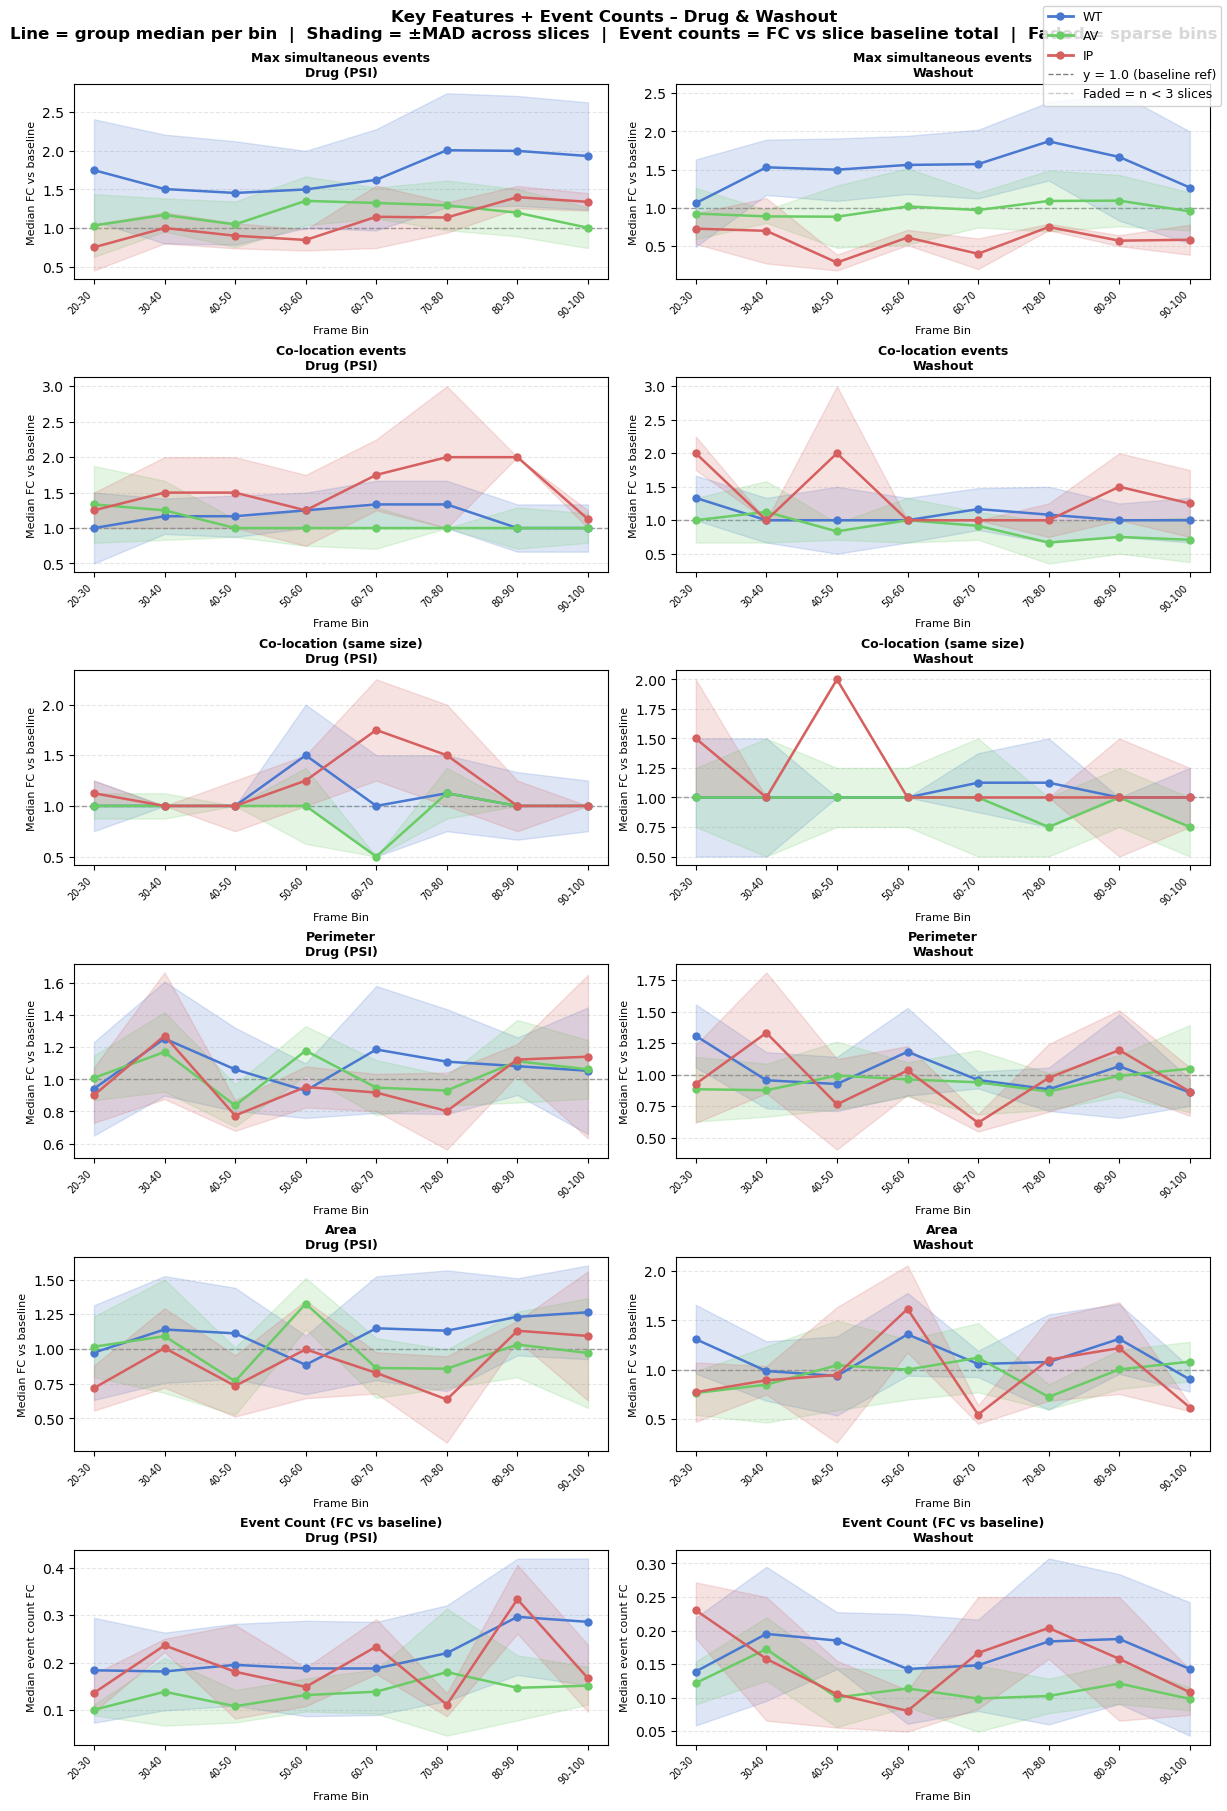

In [10]:
# ── PRIMARY: Key features + FC event counts ───────────────────────────────────
print("Plotting key features + FC event counts ...")
plot_temporal(
    data        = data,
    counts      = counts,
    features    = KEY_FEATURES,
    bin_labels  = bin_labels,
    fig_title   = (
        "Key Features + Event Counts \u2013 Drug & Washout\n"
        "Line = group median per bin  |  Shading = \u00b1MAD across slices  |  "
        "Event counts = FC vs slice baseline total  |  Faded = sparse bins"
    ),
    include_event_counts = True,
)
